In [1]:
import os
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from IPython.display import HTML

# Optional XLA JIT toggle for extra speed. Set to False if you see instability.
ENABLE_XLA = True
tf.config.optimizer.set_jit(ENABLE_XLA)
print("XLA JIT enabled:", ENABLE_XLA)

# Use GPU when available and enable mixed precision for faster training on Kaggle GPUs.
gpus = tf.config.list_physical_devices("GPU")
print("GPUs available:", gpus)
if gpus:
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision enabled:", tf.keras.mixed_precision.global_policy())
else:
    print("Running on CPU")

2026-04-18 17:39:50.146335: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776533990.303618      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776533990.351355      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776533990.706348      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776533990.706396      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776533990.706399      55 computation_placer.cc:177] computation placer alr

XLA JIT enabled: True
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Mixed precision enabled: <DTypePolicy "mixed_float16">


In [ ]:
IMAGE_SIZE = 256
CHANNELS = 3
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Auto-detect dataset root for both local runs and Kaggle.
candidate_roots = [
    Path("dataset"),
    Path("/kaggle/input/dataset/dataset"),
]

DATASET_ROOT = None
for root in candidate_roots:
    if (root / "train").exists() and (root / "val").exists() and (root / "test").exists():
        DATASET_ROOT = root
        break

if DATASET_ROOT is None and Path("/kaggle/input").exists():
    # Fallback search through Kaggle input datasets.
    for p in Path("/kaggle/input").rglob("train"):
        parent = p.parent
        if (parent / "val").exists() and (parent / "test").exists():
            DATASET_ROOT = parent
            break

if DATASET_ROOT is None:
    raise FileNotFoundError(
        "Could not locate dataset root with train/val/test folders. "
        "Expected something like dataset/train, dataset/val, dataset/test."
    )

print("Using dataset root:", DATASET_ROOT)

Using dataset root: /kaggle/input/datasets/abdullahwaqar8/dataset/dataset


In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_ROOT / "train",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=42,
)

class_names = train_ds.class_names
print("Classes:", class_names)
print("Number of classes:", len(class_names))

# Augmentation layers run efficiently on GPU and integrate well with tf.data pipelines.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
])

def preprocess_train(x, y):
    x = tf.cast(x, tf.float32) / 255.0
    x = data_augmentation(x, training=True)
    return x, y

# Normalize + augment with parallel map, then cache/shuffle/prefetch for throughput.
train_ds = train_ds.map(
    preprocess_train,
    num_parallel_calls=AUTOTUNE,
).cache().shuffle(1000).prefetch(AUTOTUNE)

Found 12804 files belonging to 10 classes.


I0000 00:00:1776534028.656433      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776534028.662411      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Classes: ['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Number of classes: 10


In [4]:
class_names

['Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Target_Spot',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_healthy']

In [5]:
len(class_names), class_names

(10,
 ['Tomato_Bacterial_spot',
  'Tomato_Early_blight',
  'Tomato_Late_blight',
  'Tomato_Leaf_Mold',
  'Tomato_Septoria_leaf_spot',
  'Tomato_Spider_mites_Two_spotted_spider_mite',
  'Tomato__Target_Spot',
  'Tomato__Tomato_YellowLeaf__Curl_Virus',
  'Tomato__Tomato_mosaic_virus',
  'Tomato_healthy'])

In [6]:
for image_batch, label_batch in train_ds.take(1):
    print(image_batch[0])
    print("Label index:", int(label_batch[0]))

I0000 00:00:1776534030.769130     145 service.cc:152] XLA service 0x7fa52801dd20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776534030.769166     145 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776534030.769169     145 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776534030.802230     145 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776534030.925949     145 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


tf.Tensor(
[[[0.6816  0.6426  0.6777 ]
  [0.68    0.641   0.6763 ]
  [0.6616  0.622   0.6577 ]
  ...
  [0.739   0.6997  0.735  ]
  [0.6953  0.6562  0.6914 ]
  [0.717   0.6772  0.713  ]]

 [[0.687   0.6484  0.683  ]
  [0.7036  0.6655  0.6997 ]
  [0.765   0.726   0.761  ]
  ...
  [0.786   0.7466  0.782  ]
  [0.781   0.741   0.777  ]
  [0.768   0.7285  0.764  ]]

 [[0.749   0.711   0.745  ]
  [0.6904  0.6543  0.687  ]
  [0.653   0.614   0.649  ]
  ...
  [0.7803  0.741   0.7764 ]
  [0.7695  0.7305  0.7656 ]
  [0.782   0.743   0.7783 ]]

 ...

 [[0.093   0.0863  0.1001 ]
  [0.09314 0.0873  0.09656]
  [0.09064 0.0898  0.0941 ]
  ...
  [0.6865  0.647   0.669  ]
  [0.6846  0.645   0.666  ]
  [0.711   0.6704  0.691  ]]

 [[0.0949  0.0874  0.0989 ]
  [0.0933  0.0871  0.09326]
  [0.09125 0.0892  0.08905]
  ...
  [0.672   0.63    0.653  ]
  [0.6655  0.6235  0.6465 ]
  [0.648   0.6055  0.6284 ]]

 [[0.0932  0.08704 0.09436]
  [0.0913  0.08936 0.0886 ]
  [0.0905  0.09076 0.08185]
  ...
  [0.663   0.

In [7]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_ROOT / "val",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False,
)

val_ds = val_ds.map(
    lambda x, y: (tf.cast(x, tf.float32) / 255.0, y),
    num_parallel_calls=AUTOTUNE,
).cache().prefetch(AUTOTUNE)

Found 1597 files belonging to 10 classes.


In [8]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_ROOT / "test",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False,
)

test_ds = test_ds.map(
    lambda x, y: (tf.cast(x, tf.float32) / 255.0, y),
    num_parallel_calls=AUTOTUNE,
).cache().prefetch(AUTOTUNE)

Found 1610 files belonging to 10 classes.


In [9]:
import time

BENCHMARK_BATCHES = 200
print(f"Benchmarking data pipeline with {BENCHMARK_BATCHES} batches...")

# Warm up one batch so graph tracing/startup overhead does not skew the measurement.
_ = next(iter(train_ds.take(1)))

start = time.perf_counter()
num_images = 0
num_batches = 0
for images_batch, labels_batch in train_ds.take(BENCHMARK_BATCHES):
    num_images += int(images_batch.shape[0])
    num_batches += 1

elapsed = time.perf_counter() - start
images_per_sec = num_images / elapsed if elapsed > 0 else 0.0
batches_per_sec = num_batches / elapsed if elapsed > 0 else 0.0

print(f"Processed {num_images} images in {elapsed:.2f} seconds")
print(f"Throughput: {images_per_sec:.2f} images/sec | {batches_per_sec:.2f} batches/sec")
print("Note: First full epoch may be slightly slower while cache is populated.")

Benchmarking data pipeline with 200 batches...
Processed 6372 images in 0.08 seconds
Throughput: 78838.63 images/sec | 2474.53 batches/sec
Note: First full epoch may be slightly slower while cache is populated.


In [10]:
# Compare throughput: augmented pipeline vs non-augmented pipeline.
def benchmark_ds(ds, batches=200, name="dataset"):
    _ = next(iter(ds.take(1)))
    start = time.perf_counter()
    num_images = 0
    num_batches = 0
    for images_batch, labels_batch in ds.take(batches):
        num_images += int(images_batch.shape[0])
        num_batches += 1
    elapsed = time.perf_counter() - start
    images_per_sec = num_images / elapsed if elapsed > 0 else 0.0
    print(f"{name}: {images_per_sec:.2f} images/sec over {num_batches} batches")
    return images_per_sec

benchmark_batches = BENCHMARK_BATCHES if "BENCHMARK_BATCHES" in globals() else 200

# Build a fair baseline pipeline without augmentation, but with the same optimizations.
train_plain_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_ROOT / "train",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=42,
)
train_plain_ds = train_plain_ds.map(
    lambda x, y: (tf.cast(x, tf.float32) / 255.0, y),
    num_parallel_calls=AUTOTUNE,
).cache().shuffle(1000).prefetch(AUTOTUNE)

plain_ips = benchmark_ds(train_plain_ds, benchmark_batches, "No augmentation")
aug_ips = benchmark_ds(train_ds, benchmark_batches, "With augmentation")

overhead = ((plain_ips - aug_ips) / plain_ips * 100.0) if plain_ips > 0 else 0.0
print(f"Augmentation overhead: {overhead:.2f}%")

Found 12804 files belonging to 10 classes.
No augmentation: 89191.88 images/sec over 200 batches
With augmentation: 70672.42 images/sec over 200 batches
Augmentation overhead: 20.76%


In [11]:
for image_batch, label_batch in test_ds.take(1):
    print(image_batch[0])
    print("Label index:", int(label_batch[0]))

tf.Tensor(
[[[0.4392157  0.41960785 0.40784314]
  [0.44313726 0.42352942 0.4117647 ]
  [0.5254902  0.5058824  0.49411765]
  ...
  [0.5411765  0.52156866 0.50980395]
  [0.50980395 0.49019608 0.47843137]
  [0.46666667 0.44705883 0.43529412]]

 [[0.48235294 0.4627451  0.4509804 ]
  [0.5254902  0.5058824  0.49411765]
  [0.5647059  0.54509807 0.53333336]
  ...
  [0.4862745  0.46666667 0.45490196]
  [0.5294118  0.50980395 0.49803922]
  [0.5882353  0.5686275  0.5568628 ]]

 [[0.53333336 0.5137255  0.5019608 ]
  [0.5568628  0.5372549  0.5254902 ]
  [0.5686275  0.54901963 0.5372549 ]
  ...
  [0.4509804  0.43137255 0.41960785]
  [0.44313726 0.42352942 0.4117647 ]
  [0.49803922 0.47843137 0.46666667]]

 ...

 [[0.5686275  0.56078434 0.57254905]
  [0.57254905 0.5647059  0.5764706 ]
  [0.5764706  0.5686275  0.5803922 ]
  ...
  [0.627451   0.61960787 0.62352943]
  [0.627451   0.61960787 0.62352943]
  [0.6313726  0.62352943 0.627451  ]]

 [[0.5647059  0.5568628  0.5686275 ]
  [0.57254905 0.5647059  0

In [40]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = len(class_names)

model = models.Sequential([
    layers.InputLayer(shape=input_shape),
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    # Keep output in float32 for numerically stable softmax with mixed precision.
    layers.Dense(n_classes, activation="softmax", dtype="float32"),
])

In [41]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,202 (719.54 KB)

 Trainable params: 184,202 (719.54 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [43]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    verbose=1,
)

Epoch 1/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 23s 44ms/step - accuracy: 0.2961 - loss: 1.9380 - val_accuracy: 0.5704 - val_loss: 1.2743
Epoch 2/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.6362 - loss: 1.0420 - val_accuracy: 0.6744 - val_loss: 1.0507
Epoch 3/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.7839 - loss: 0.6178 - val_accuracy: 0.8153 - val_loss: 0.5401
Epoch 4/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.8385 - loss: 0.4509 - val_accuracy: 0.7740 - val_loss: 0.7112
Epoch 5/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.8738 - loss: 0.3658 - val_accuracy: 0.8823 - val_loss: 0.3360
Epoch 6/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.9048 - loss: 0.2687 - val_accuracy: 0.8303 - val_loss: 0.6340
Epoch 7/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.9188 - loss: 0.2241 - val_accuracy: 0.8140 - val_loss: 0.6092
Epoch 8/30
401/401 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.9357 - loss: 0.1809 - 

In [44]:
scores = model.evaluate(test_ds)

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8705 - loss: 0.5627


In [45]:
scores

[0.5739136338233948, 0.8968943953514099]

In [46]:
history

In [47]:
history.params

{'verbose': 1, 'epochs': 30, 'steps': 401}

In [48]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [49]:
type(history.history['loss'])

list

In [50]:
len(history.history['loss'])

30

In [51]:
history.history['loss'][:5]

[1.677416443824768,
 0.9279220104217529,
 0.570939838886261,
 0.42378848791122437,
 0.3488388657569885]

In [52]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

In [53]:
val_acc

[0.5704445838928223,
 0.6743894815444946,
 0.8152786493301392,
 0.7739511728286743,
 0.8822792768478394,
 0.8303068280220032,
 0.8140262961387634,
 0.7977457642555237,
 0.9142141342163086,
 0.9167188405990601,
 0.8960551023483276,
 0.9023168683052063,
 0.8948027491569519,
 0.9085785746574402,
 0.8973074555397034,
 0.8998121619224548,
 0.9254853129386902,
 0.9317470192909241,
 0.871634304523468,
 0.8346900343894958,
 0.9123356342315674,
 0.9286161661148071,
 0.9104571342468262,
 0.9085785746574402,
 0.8591108322143555,
 0.9104571342468262,
 0.9411396384239197,
 0.9142141342163086,
 0.919849693775177,
 0.9135879874229431]

In [54]:
acc

[0.40143704414367676,
 0.6744767427444458,
 0.7969384789466858,
 0.8507497906684875,
 0.8822243213653564,
 0.9055764079093933,
 0.9208840727806091,
 0.9289284348487854,
 0.9426741600036621,
 0.9511871337890625,
 0.9484536051750183,
 0.9459543824195862,
 0.9626679420471191,
 0.9643080234527588,
 0.9746953845024109,
 0.9641517996788025,
 0.973133385181427,
 0.9729772210121155,
 0.9703998565673828,
 0.9756326079368591,
 0.9761012196540833,
 0.9806310534477234,
 0.974929690361023,
 0.9822711944580078,
 0.9793033599853516,
 0.9716494679450989,
 0.9889097213745117,
 0.9801624417304993,
 0.9833645820617676,
 0.9832083582878113]

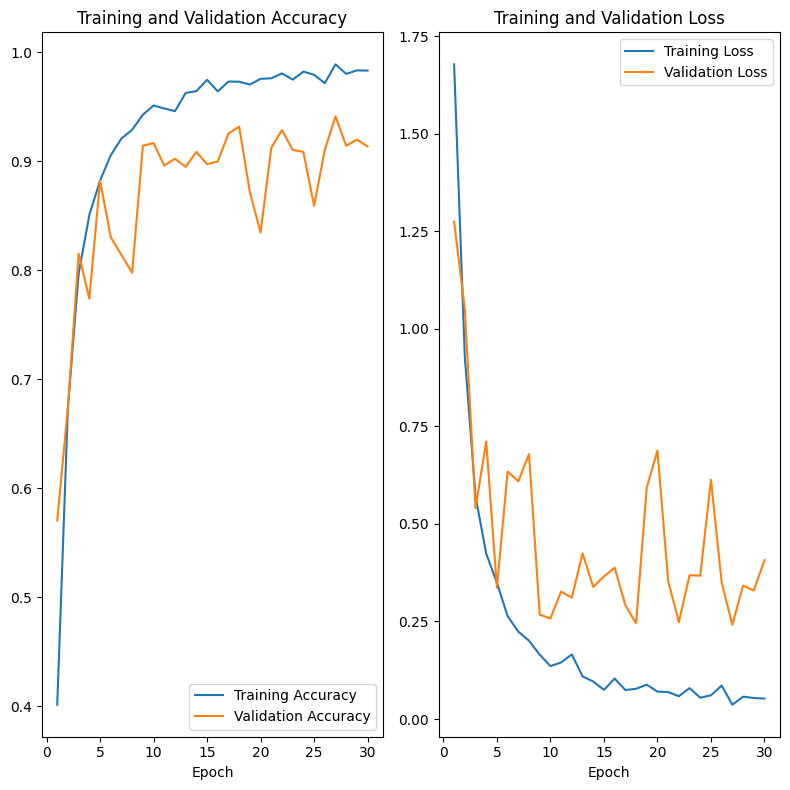

In [55]:
epochs_ran = min(len(acc), len(val_acc), len(loss), len(val_loss))
epoch_range = range(1, epochs_ran + 1)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epoch_range, acc[:epochs_ran], label="Training Accuracy")
plt.plot(epoch_range, val_acc[:epochs_ran], label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")

plt.subplot(1, 2, 2)
plt.plot(epoch_range, loss[:epochs_ran], label="Training Loss")
plt.plot(epoch_range, val_loss[:epochs_ran], label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.tight_layout()
plt.show()

First image to predict
Actual label: Tomato_Bacterial_spot
Predicted label: Tomato_Bacterial_spot


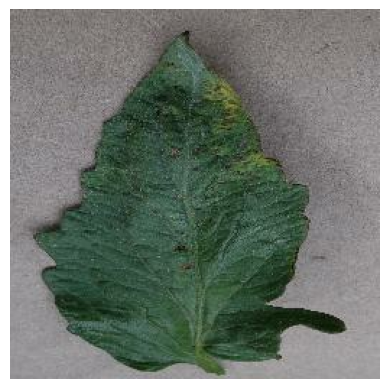

In [56]:
import numpy as np

for images_batch, labels_batch in test_ds.take(1):
    first_image = images_batch[0]
    first_label = int(labels_batch[0])

    print("First image to predict")
    plt.imshow(first_image)
    plt.axis("off")
    print("Actual label:", class_names[first_label])

    batch_prediction = model.predict(images_batch, verbose=0)
    print("Predicted label:", class_names[np.argmax(batch_prediction[0])])

In [57]:
def predict(model, img):
    img_array = tf.expand_dims(img, 0)
    predictions = model.predict(img_array, verbose=0)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * float(np.max(predictions[0])), 2)
    return predicted_class, confidence

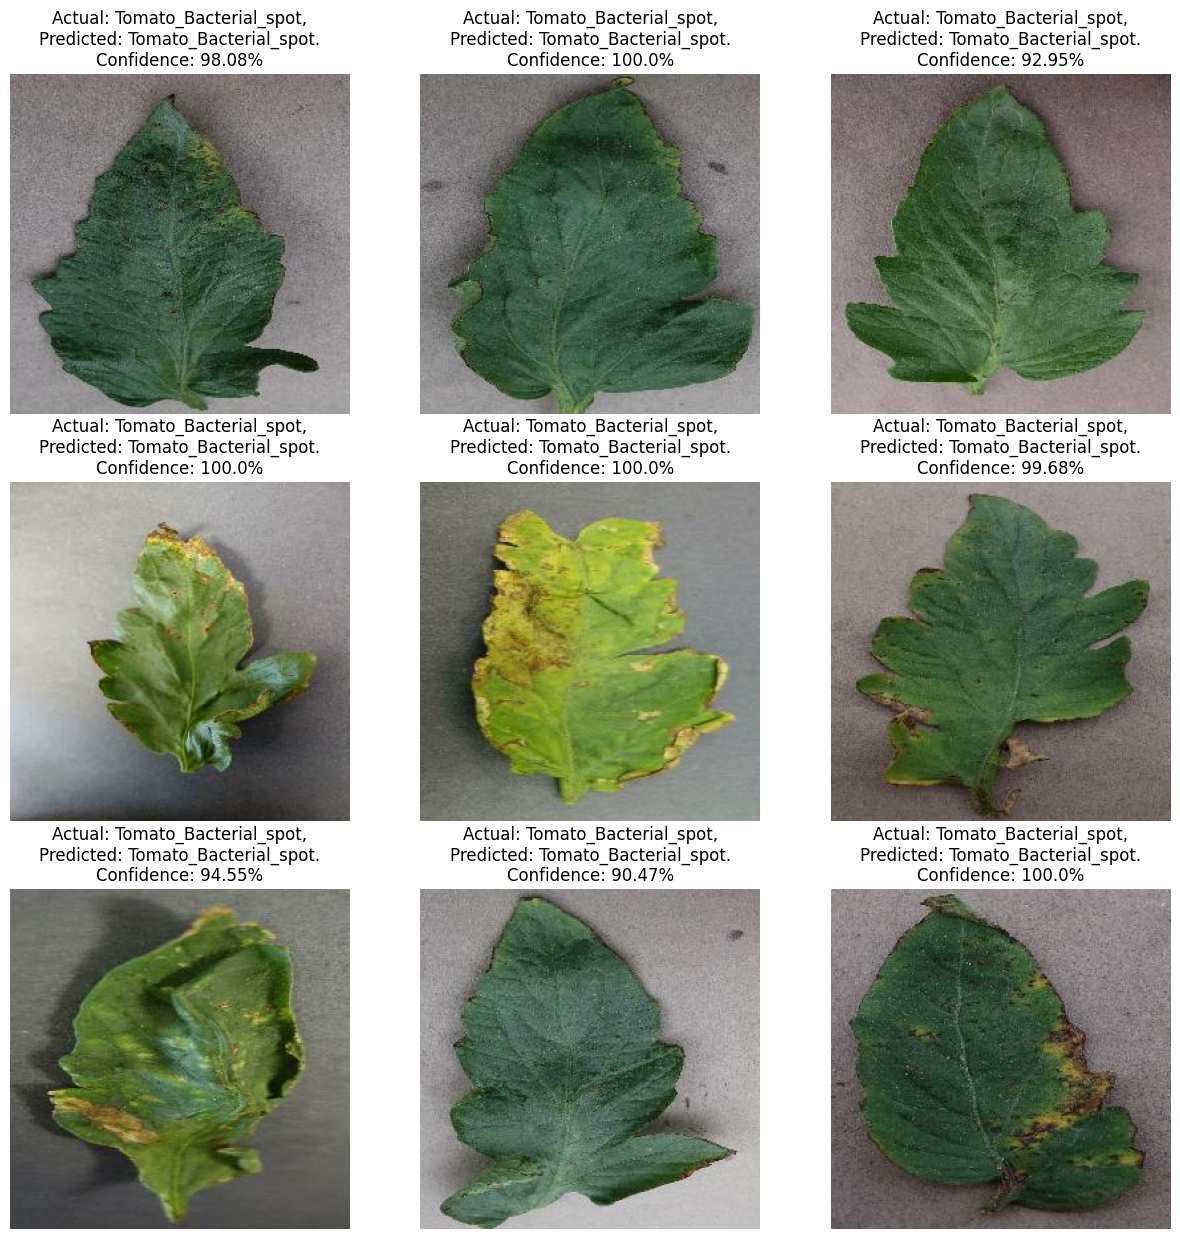

In [58]:
plt.figure(figsize=(15, 15))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])

        predicted_class, confidence = predict(model, images[i])
        actual_class = class_names[int(labels[i])]

        plt.title(f"Actual: {actual_class},\nPredicted: {predicted_class}.\nConfidence: {confidence}%")
        plt.axis("off")

In [61]:
model.save("./tomatoes.keras")